In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import requests
import io
from sklearn.model_selection import train_test_split

In [3]:
# historical_url = 'https://en.wikipedia.org/w/index.php?title=NIFTY_500&oldid=1166112577#Constituents' # 13 July 2023
historical_url = 'https://en.wikipedia.org/w/index.php?title=NIFTY_500&oldid=1266850784#Constituents' # 26 Nov 2024

tables = pd.read_html(
    historical_url,
    match='Symbol', 
    storage_options={'User-Agent': 'Mozilla/5.0'}
)

nifty500_df = tables[0]
header = nifty500_df.iloc[0]
nifty500_df = nifty500_df[1:]
nifty500_df.columns = header
nifty500_df = nifty500_df.reset_index(drop=True)

tickers = nifty500_df['Symbol'].astype(str) + '.NS'

print("Historical Constituents List:")
print(tickers.tolist())

Historical Constituents List:
['360ONE.NS', '3MINDIA.NS', 'ABB.NS', 'ACC.NS', 'AIAENG.NS', 'APLAPOLLO.NS', 'AUBANK.NS', 'AARTIIND.NS', 'AAVAS.NS', 'ABBOTINDIA.NS', 'ACE.NS', 'ADANIENSOL.NS', 'ADANIENT.NS', 'ADANIGREEN.NS', 'ADANIPORTS.NS', 'ADANIPOWER.NS', 'ATGL.NS', 'AWL.NS', 'ABCAPITAL.NS', 'ABFRL.NS', 'AEGISLOG.NS', 'AETHER.NS', 'AFFLE.NS', 'AJANTPHARM.NS', 'APLLTD.NS', 'ALKEM.NS', 'ALKYLAMINE.NS', 'ALLCARGO.NS', 'ALOKINDS.NS', 'ARE&M.NS', 'AMBER.NS', 'AMBUJACEM.NS', 'ANANDRATHI.NS', 'ANGELONE.NS', 'ANURAS.NS', 'APARINDS.NS', 'APOLLOHOSP.NS', 'APOLLOTYRE.NS', 'APTUS.NS', 'ACI.NS', 'ASAHIINDIA.NS', 'ASHOKLEY.NS', 'ASIANPAINT.NS', 'ASTERDM.NS', 'ASTRAZEN.NS', 'ASTRAL.NS', 'ATUL.NS', 'AUROPHARMA.NS', 'AVANTIFEED.NS', 'DMART.NS', 'AXISBANK.NS', 'BEML.NS', 'BLS.NS', 'BSE.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BAJAJHLDNG.NS', 'BALAMINES.NS', 'BALKRISIND.NS', 'BALRAMCHIN.NS', 'BANDHANBNK.NS', 'BANKBARODA.NS', 'BANKINDIA.NS', 'MAHABANK.NS', 'BATAINDIA.NS', 'BAYERCROP.NS', 

In [4]:
tickers = nifty500_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()

# 2 years:
# raw_train_data = yf.download(tickers_list, start='2020-04-01', end='2024-03-31', interval='1d')
# raw_test_data = yf.download(tickers_list, start='2024-04-01', interval='1d')

# 1 year:
raw_train_data = yf.download(tickers_list, start='2021-04-01', end='2025-03-31', interval='1d')
raw_test_data = yf.download(tickers_list, start='2025-04-01', interval='1d')

/tmp/ipykernel_7649/864968371.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_train_data = yf.download(tickers_list, start='2021-04-01', end='2025-03-31', interval='1d')
[***                    7%                       ]  33 of 500 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SUVENPHAR.NS"}}}
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
9 Failed downloads:
ERROR:yfinance:['SUVENPHAR.NS', 'GLS.NS', 'GMRINFRA.NS', 'HBLPOWER.NS', 'PEL.NS', 'ZOMATO.NS', 'TATAMOTORS.NS', 'SWANENERGY.NS', 'ISEC.NS']: YFTzMissingError('possibly delisted; no timezone found')
/tmp/ipykernel_7649/864968371.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_test_data = yf.download(tickers_list, start='2025-04-01', interval='1d')
[*********************100%***********************]  500 of 500 com

In [5]:
# nifty50_index = yf.download('^NSEI', start='2024-04-01', interval='1d')
nifty500_index = yf.download('^CRSLDX', start='2025-04-01', interval='1d')

/tmp/ipykernel_7649/1052875531.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty500_index = yf.download('^CRSLDX', start='2025-04-01', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [6]:
close_train_prices = raw_train_data['Close']
close_test_prices = raw_test_data['Close']
benchmark = nifty500_index['Close']

In [7]:
display(close_train_prices.isna().sum())
display(close_test_prices.isna().sum())
display(benchmark.isna().sum())

,0
Ticker,
360ONE.NS,0
3MINDIA.NS,0
AARTIIND.NS,0
AAVAS.NS,0
ABB.NS,0
...,...
ZEEL.NS,0
ZENSARTECH.NS,0
ZFCVINDIA.NS,0


,0
Ticker,
360ONE.NS,1
3MINDIA.NS,1
AARTIIND.NS,0
AAVAS.NS,0
ABB.NS,0
...,...
ZEEL.NS,0
ZENSARTECH.NS,0
ZFCVINDIA.NS,0


,0
Ticker,
^CRSLDX,0


In [ ]:
'''common_cols = close_train_prices.columns.intersection(close_test_prices.columns)

valid_cols = [
    c for c in common_cols
    if close_train_prices[c].notna().all() and close_test_prices[c].notna().all()
]

close_train_prices = close_train_prices.loc[:, valid_cols]
close_test_prices = close_test_prices.loc[:, valid_cols]'''

In [8]:
common_cols = close_train_prices.columns.intersection(close_test_prices.columns)

# Keep columns where total NaNs across train+test is at most 1
valid_cols = [
    c for c in common_cols
    if (close_train_prices[c].isna().sum() + close_test_prices[c].isna().sum()) <= 1
]

close_train_prices = close_train_prices.loc[:, valid_cols].ffill()
close_test_prices = close_test_prices.loc[:, valid_cols].ffill()

In [9]:
display(close_train_prices.columns.value_counts().sum())
display(close_test_prices.columns.value_counts().sum())

np.int64(430)

np.int64(430)

In [10]:
log_returns = np.log(close_train_prices/close_train_prices.shift(1)).dropna()

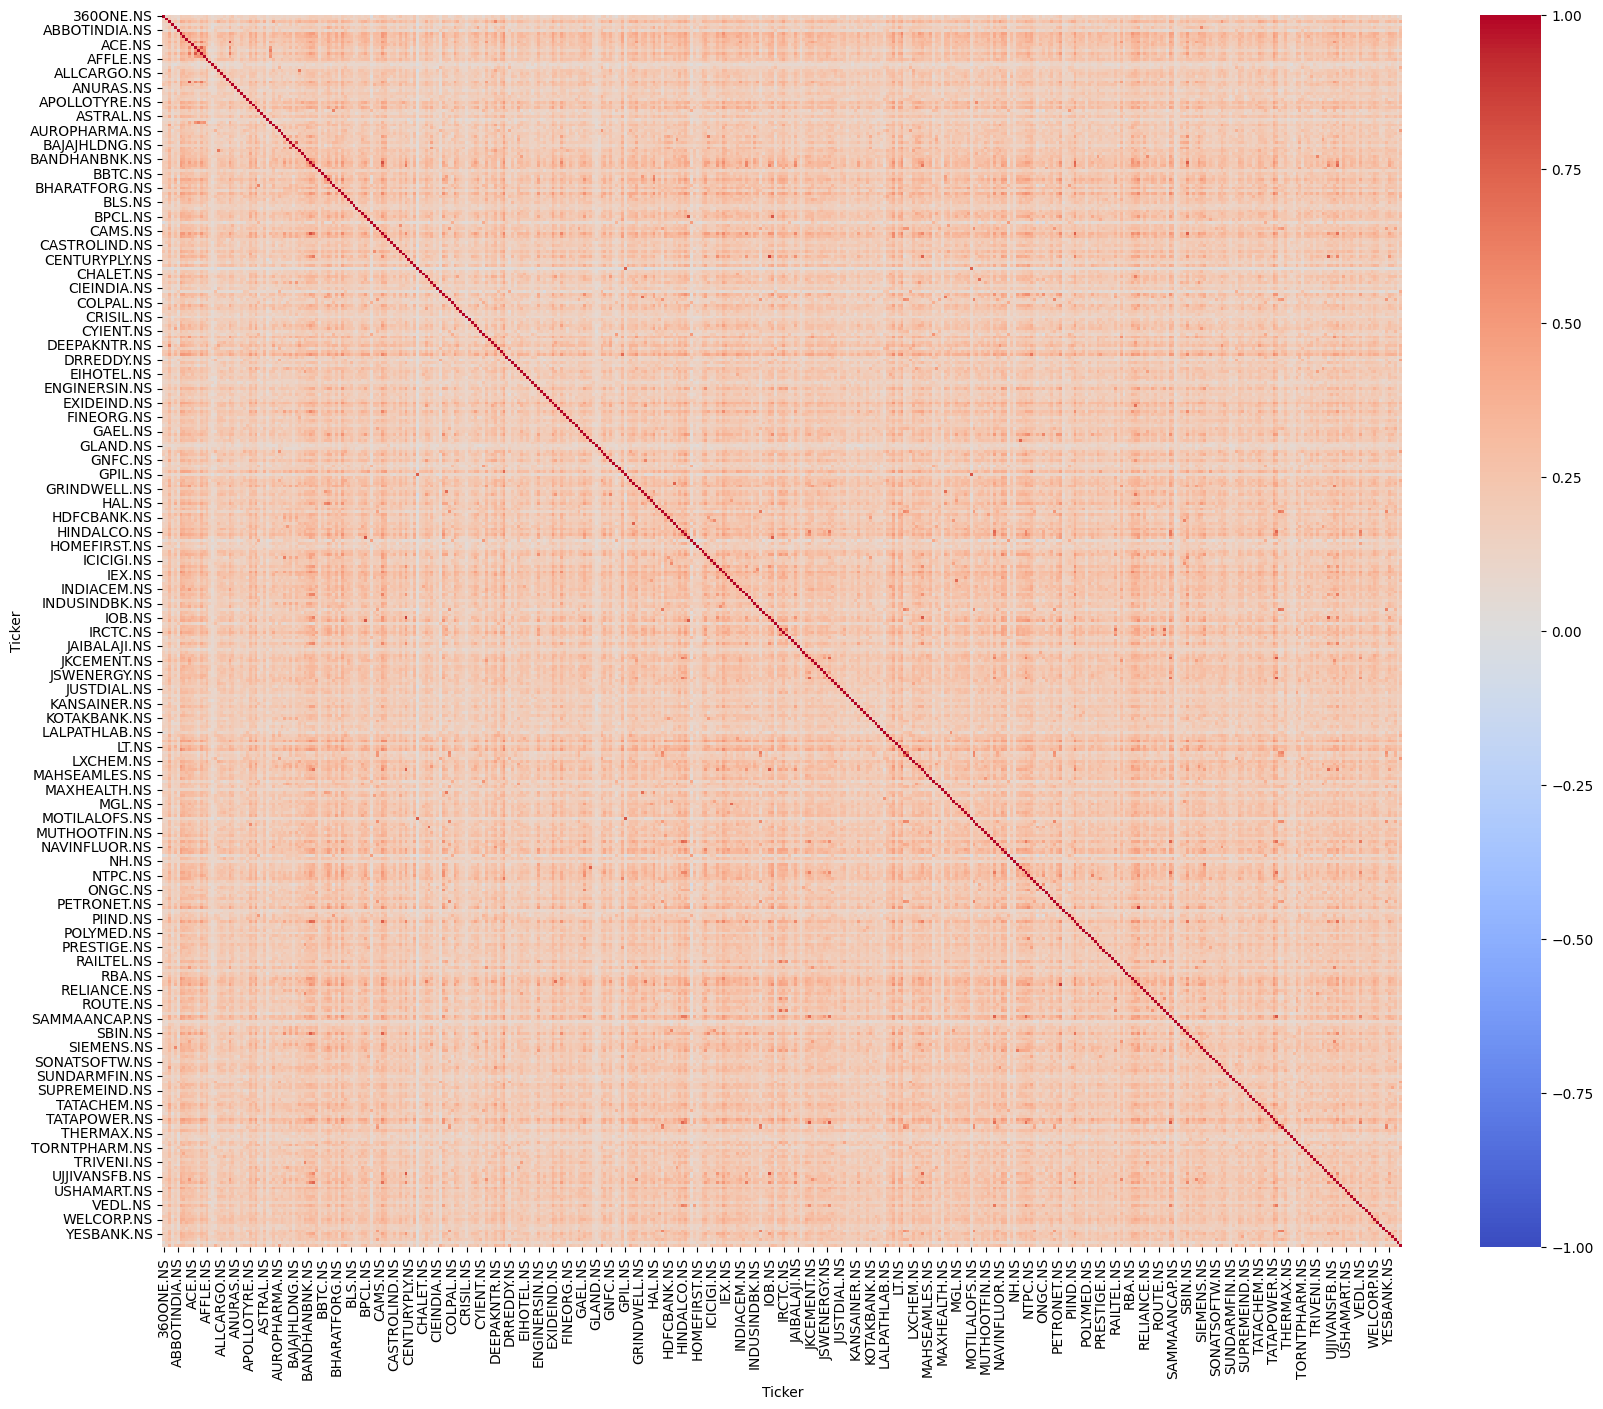

In [11]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [12]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [13]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([97.17077244, 10.62262323,  6.7590691 ,  5.7080579 ,  4.94903413,
        4.2672115 ,  3.79019636,  3.43681198,  3.05011022,  2.93272164])

array([0.22574959, 0.02467875, 0.01570284, 0.0132611 , 0.01149772,
       0.00991369, 0.00880548, 0.00798449, 0.00708609, 0.00681337])

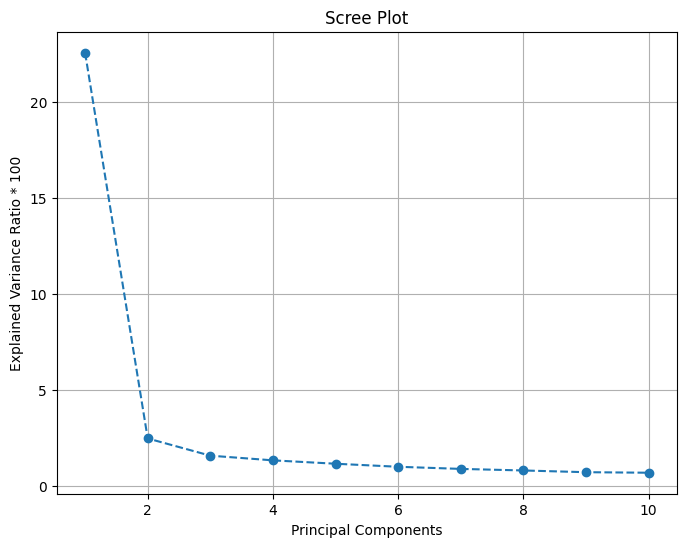

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [15]:
industry_map = (nifty500_df[['Symbol', 'Industry']].drop_duplicates('Symbol').set_index('Symbol')['Industry'])

In [16]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
118,DLF.NS,7.522192,Realty
385,TATAPOWER.NS,7.316046,Power
76,CANBK.NS,7.221726,Financial Services
253,LICHSGFIN.NS,7.184202,Financial Services
256,LTF.NS,7.111097,Financial Services
62,BHEL.NS,7.042433,Capital Goods
349,SAIL.NS,7.000439,Metals & Mining
194,IDFCFIRSTB.NS,6.942256,Financial Services
181,HINDCOPPER.NS,6.928794,Metals & Mining
6,ABCAPITAL.NS,6.856121,Financial Services


,Ticker,Weight,Industry
36,ASTRAZEN.NS,2.387840,Healthcare
105,CRISIL.NS,2.327296,Financial Services
160,GPIL.NS,2.304882,Capital Goods
150,GLAND.NS,2.253607,Healthcare
183,HINDUNILVR.NS,2.224249,Fast Moving Consumer Goods
72,BRITANNIA.NS,2.211524,Fast Moving Consumer Goods
17,AJANTPHARM.NS,2.052661,Healthcare
351,SANOFI.NS,1.968651,Healthcare
96,CIPLA.NS,1.823627,Healthcare
88,CGCL.NS,1.029424,Financial Services


In [17]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
207,INFY.NS,14.525520,Information Technology
387,TCS.NS,13.585424,Information Technology
183,HINDUNILVR.NS,13.576437,Fast Moving Consumer Goods
257,LTIM.NS,13.313354,Information Technology
173,HCLTECH.NS,13.072775,Information Technology
388,TECHM.NS,12.692470,Information Technology
293,NESTLEIND.NS,12.627244,Fast Moving Consumer Goods
33,ASIANPAINT.NS,12.198728,Consumer Durables
424,WIPRO.NS,12.125350,Information Technology
111,DABUR.NS,11.990132,Fast Moving Consumer Goods


,Ticker,Weight,Industry
214,IRCON.NS,-8.668944,Construction
188,HUDCO.NS,-8.713230,Financial Services
347,RVNL.NS,-8.787762,Construction
216,IRFC.NS,-8.799788,Financial Services
343,RITES.NS,-8.961404,Construction
361,SJVN.NS,-9.305185,Power
263,MAHABANK.NS,-9.915061,Financial Services
404,UCOBANK.NS,-10.063874,Financial Services
210,IOB.NS,-10.141361,Financial Services
84,CENTRALBK.NS,-11.456968,Financial Services


In [20]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
355,SBIN.NS,16.510887,Financial Services
42,AXISBANK.NS,15.346357,Financial Services
189,ICICIBANK.NS,15.118473,Financial Services
51,BANKBARODA.NS,14.416969,Financial Services
76,CANBK.NS,12.825867,Financial Services
46,BAJFINANCE.NS,12.346976,Financial Services
245,KOTAKBANK.NS,12.126308,Financial Services
44,BAJAJFINSV.NS,12.074942,Financial Services
316,PNB.NS,11.711897,Financial Services
175,HDFCBANK.NS,10.811464,Financial Services


,Ticker,Weight,Industry
309,PERSISTENT.NS,-7.902040,Information Technology
74,BSOFT.NS,-8.183065,Information Technology
144,FSL.NS,-8.422348,Services
258,LTTS.NS,-8.630384,Information Technology
257,LTIM.NS,-8.857450,Information Technology
269,MASTEK.NS,-9.177398,Information Technology
427,ZENSARTECH.NS,-9.262136,Information Technology
365,SONATSOFTW.NS,-9.701943,Information Technology
122,ECLERX.NS,-10.197616,Services
99,COFORGE.NS,-10.897709,Information Technology


In [21]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
180,HINDALCO.NS,18.068150,Metals & Mining
386,TATASTEEL.NS,16.685980,Metals & Mining
288,NATIONALUM.NS,16.054592,Metals & Mining
305,ONGC.NS,15.665512,Oil Gas & Consumable Fuels
231,JSWSTEEL.NS,15.483234,Metals & Mining
349,SAIL.NS,15.421208,Metals & Mining
173,HCLTECH.NS,15.416239,Information Technology
224,JINDALSTEL.NS,15.058015,Metals & Mining
388,TECHM.NS,14.920292,Information Technology
299,NMDC.NS,14.579148,Metals & Mining


,Ticker,Weight,Industry
72,BRITANNIA.NS,-8.033221,Fast Moving Consumer Goods
33,ASIANPAINT.NS,-8.100103,Consumer Durables
329,RADICO.NS,-8.152909,Fast Moving Consumer Goods
240,KANSAINER.NS,-8.221956,Consumer Durables
314,PIDILITIND.NS,-8.282735,Chemicals
111,DABUR.NS,-8.435747,Fast Moving Consumer Goods
204,INDIGOPNTS.NS,-8.612470,Consumer Durables
129,ENDURANCE.NS,-9.022408,Automobile and Auto Components
157,GODREJCP.NS,-9.870899,Fast Moving Consumer Goods
183,HINDUNILVR.NS,-10.428594,Fast Moving Consumer Goods


### Performance Measurement

In [31]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = 100/ pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),6.51%,6.08%
Volatility,16.81%,15.01%
Sharpe Ratio,0.03,0.01
Sortino Ratio,0.04,0.01
Max Drawdown,-16.80%,-14.82%
Calmar Ratio,0.39,0.41
Beta,1.07,1.00
Jensen's Alpha,0.43%,0.00%


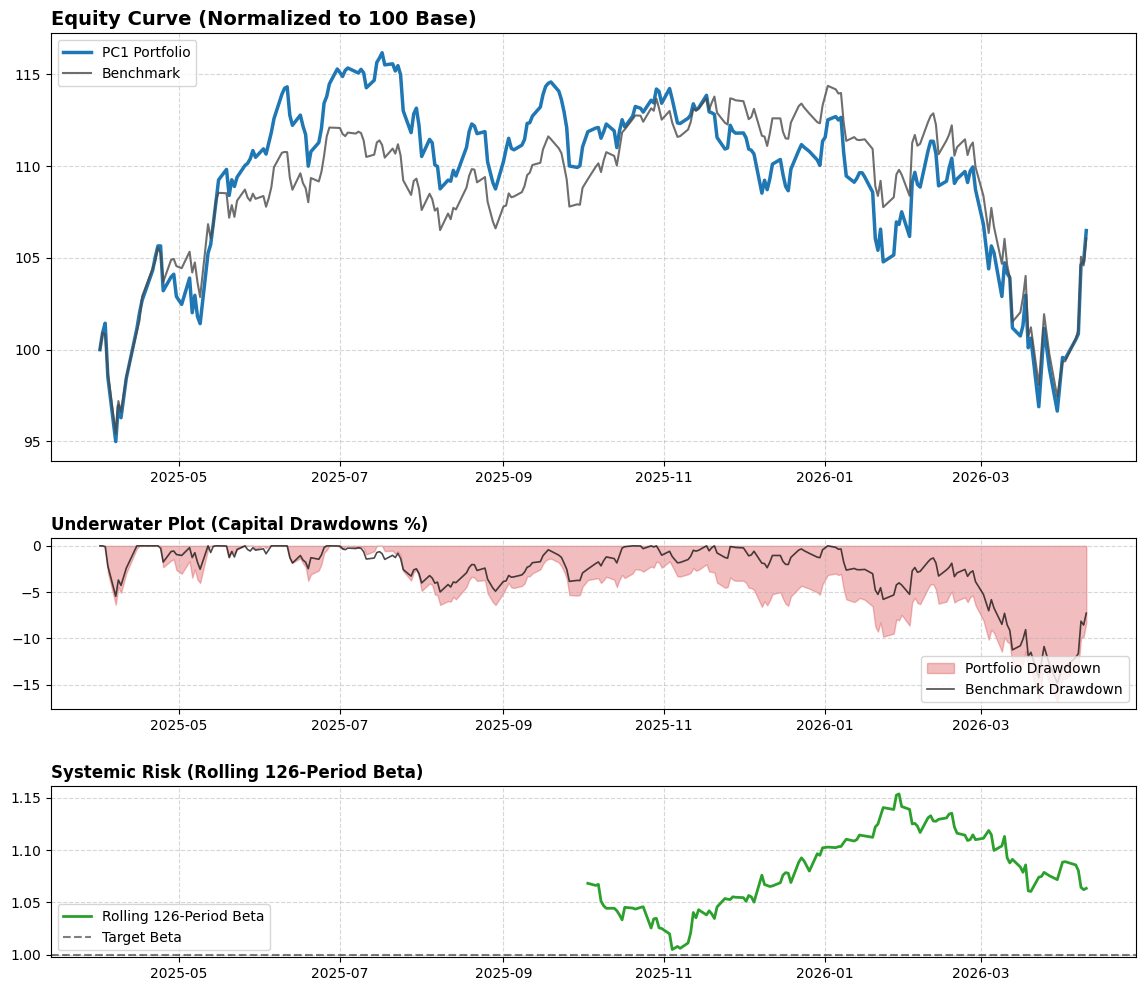

In [32]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-8.73%,6.08%
Volatility,14.88%,15.01%
Sharpe Ratio,-0.99,0.01
Sortino Ratio,-1.38,0.01
Max Drawdown,-20.23%,-14.82%
Calmar Ratio,-0.43,0.41
Beta,-0.11,1.00
Jensen's Alpha,-14.72%,0.00%


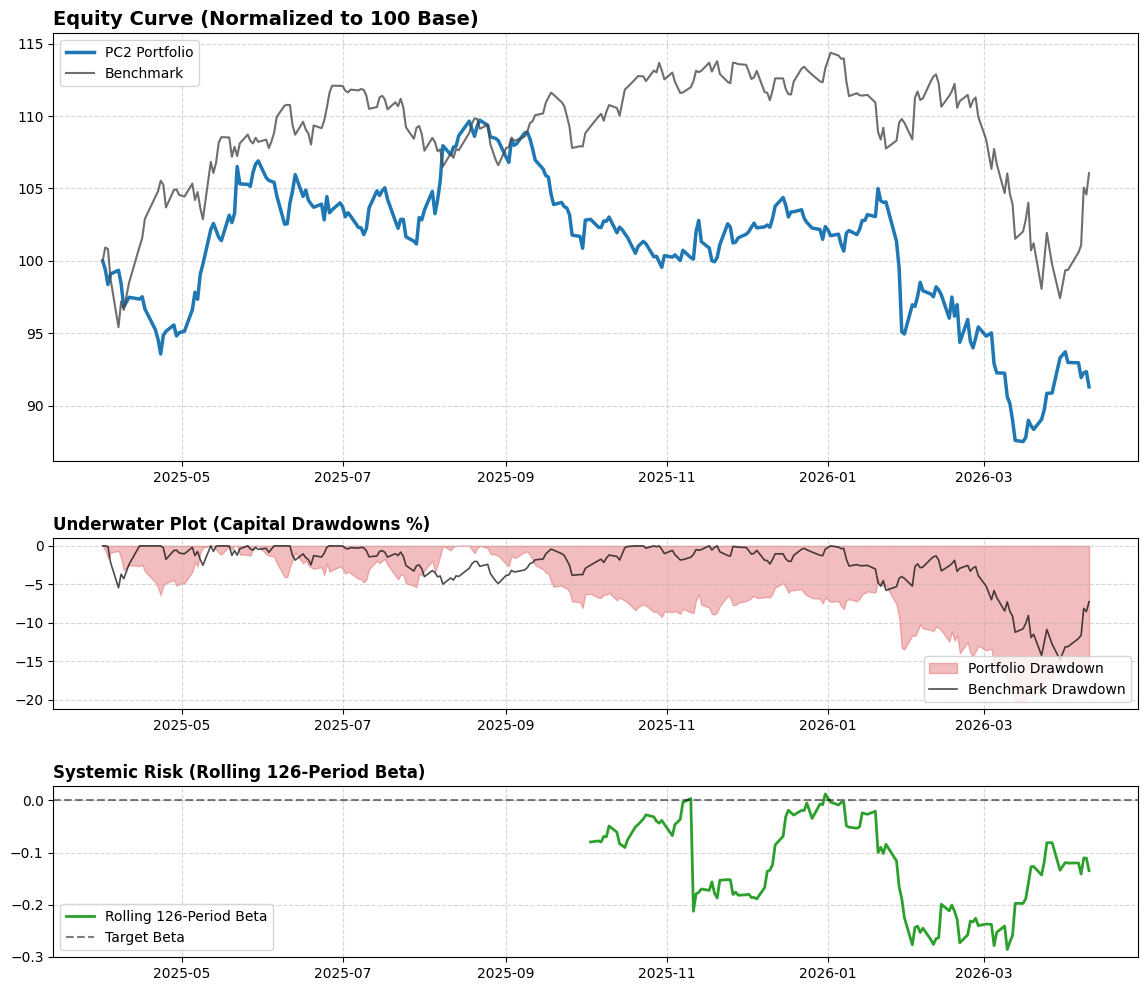

In [33]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-33.09%,6.08%
Volatility,22.71%,15.01%
Sharpe Ratio,-1.72,0.01
Sortino Ratio,-2.61,0.01
Max Drawdown,-35.49%,-14.82%
Calmar Ratio,-0.93,0.41
Beta,-0.10,1.00
Jensen's Alpha,-39.09%,0.00%


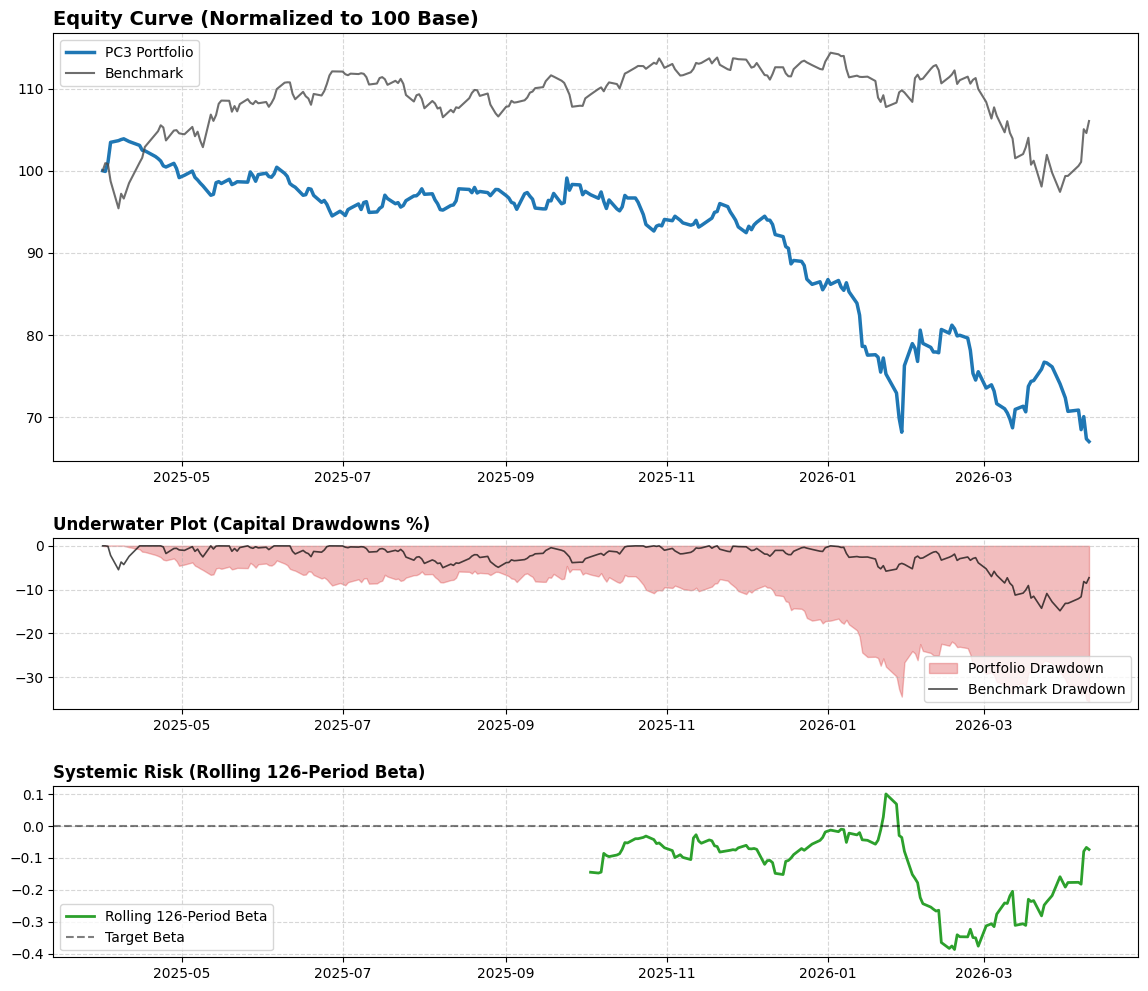

In [34]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),11.51%,6.08%
Volatility,13.00%,15.01%
Sharpe Ratio,0.42,0.01
Sortino Ratio,0.66,0.01
Max Drawdown,-6.31%,-14.82%
Calmar Ratio,1.83,0.41
Beta,0.26,1.00
Jensen's Alpha,5.49%,0.00%


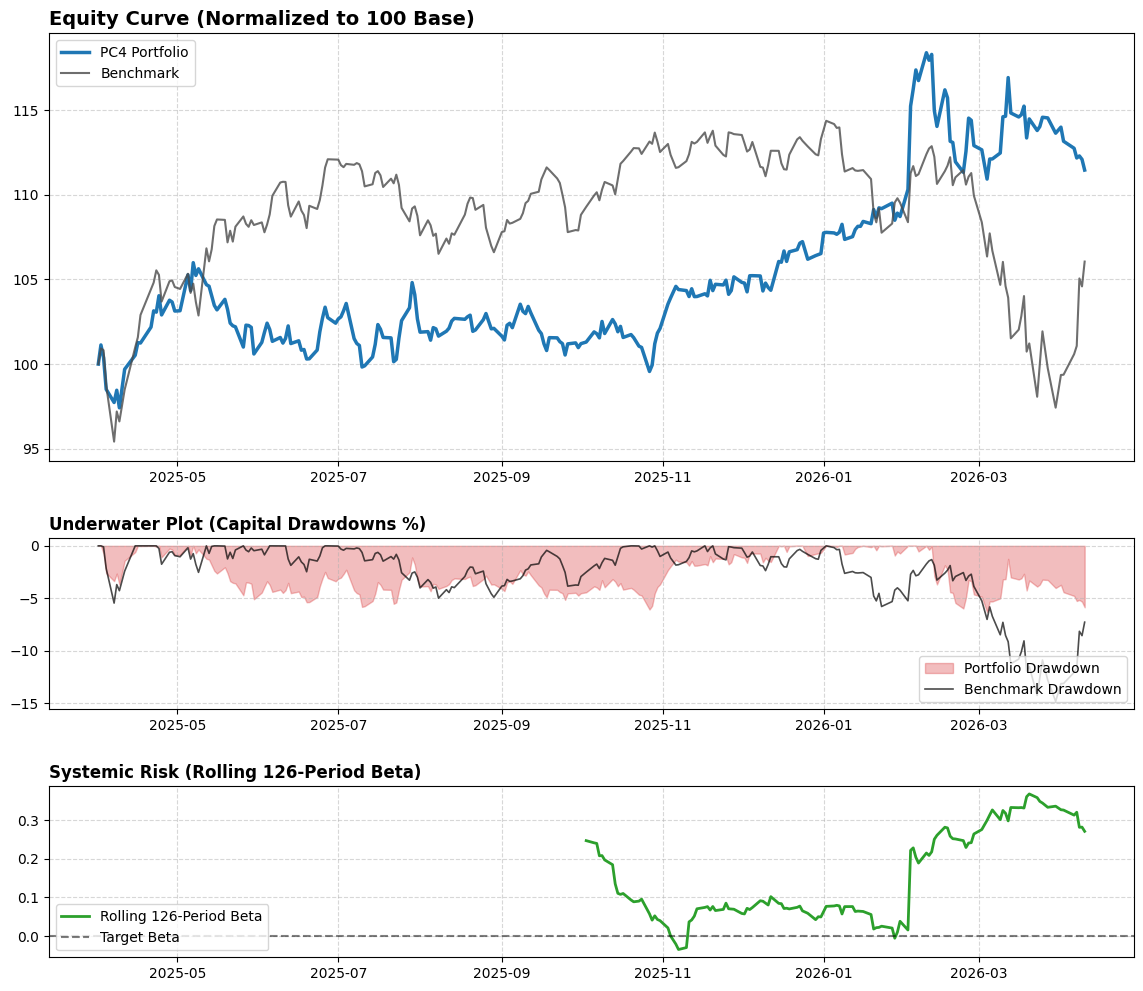

In [35]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 MULTI-FACTOR PORTFOLIO: PC2 + PC3 + PC4 (Equal Weighting)


,Portfolio,Benchmark
Return (CAGR),-10.11%,6.08%
Volatility,9.71%,15.01%
Sharpe Ratio,-1.66,0.01
Sortino Ratio,-2.34,0.01
Max Drawdown,-12.98%,-14.82%
Calmar Ratio,-0.78,0.41
Beta,0.03,1.00
Jensen's Alpha,-16.11%,0.00%


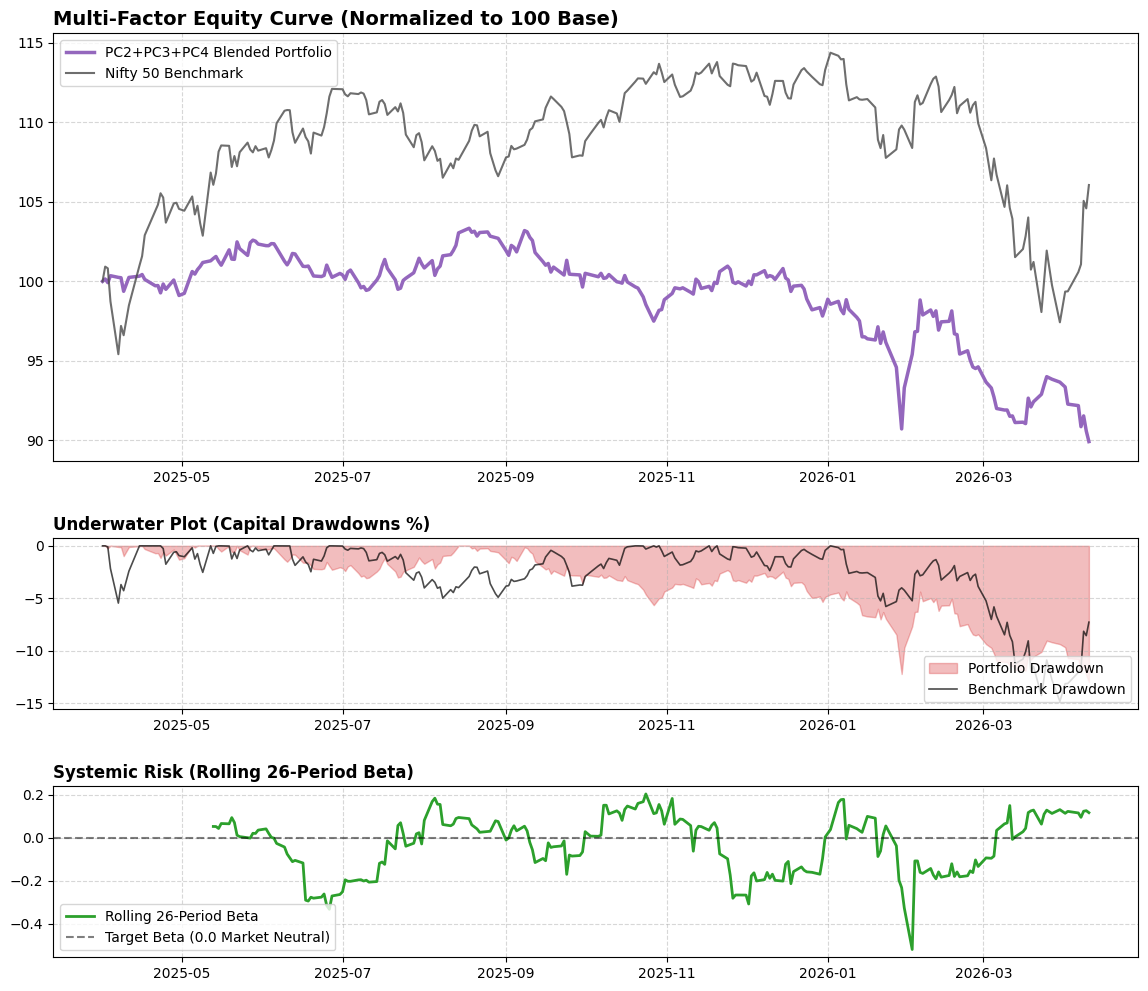

In [ ]:
# ==============================================================================
# 1. MULTI-FACTOR WEIGHT GENERATOR
# ==============================================================================
def get_combined_multi_pc_weights(pca_model, columns, pc_indices, allocations):
    """
    Combines multiple Principal Components into a single weighted portfolio.
    Assumes all provided components are traded as Market-Neutral Long/Short.
    """
    # Start with a blank slate of 0.0 weights for all stocks
    combined_weights = pd.Series(0.0, index=columns)
    
    for pc_idx, alloc in zip(pc_indices, allocations):
        # Extract raw weights for this component
        raw_weights = pca_model.components_[pc_idx]
        
        # Normalize as Long/Short (+1.0 Longs, -1.0 Shorts)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        
        # This component's final normalized weights
        pc_weights = pd.Series(norm_longs + norm_shorts, index=columns)
        
        # Apply the allocation multiplier and add to the master portfolio
        combined_weights += (pc_weights * alloc)
        
    return combined_weights

# ==============================================================================
# 2. EXECUTION & DASHBOARD 
# ==============================================================================

# We want PC2 (Index 1), PC3 (Index 2), and PC4 (Index 3)
indices_to_combine = [1, 2, 3] 

# Equal weightage: 33.33% allocated to each component
allocations = [1/3, 1/3, 1/3]

# Generate the Master Blended Weights
master_weights = get_combined_multi_pc_weights(pca, close_test_prices.columns, indices_to_combine, allocations)

# Since PC2, 3, and 4 are all Market-Neutral spreads, the combined portfolio is also Long/Short
combined_port_val = simulate_portfolio(
    price_data=close_test_prices, 
    weights=master_weights, 
    initial_capital=100000, 
    strategy_name='Long/Short'
)
bench_val = align_benchmark(benchmark, initial_capital=100000)

# Calculate Institutional Metrics (Using 52 for Weekly data, change to 252 if using Daily)
metrics_df_combo, p_dd, b_dd, p_ret, b_ret = calculate_metrics(
    port_val=combined_port_val, 
    bench_val=bench_val, 
    rf_rate=0.06, 
    periods_per_yr=252
)

# --- Print Results ---
print("\n" + "="*70)
print(" MULTI-FACTOR PORTFOLIO: PC2 + PC3 + PC4 (Equal Weighting)")
print("="*70)
display(metrics_df_combo)

# --- Render Custom Dashboard ---
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)

# Chart 1: Equity Curve
ax1 = fig.add_subplot(gs[0])
ax1.plot(combined_port_val.index, (combined_port_val/100000)*100, label='PC2+PC3+PC4 Blended Portfolio', color='#9467bd', linewidth=2.5)
ax1.plot(bench_val.index, (bench_val/100000)*100, label='Nifty 50 Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
ax1.set_title('Multi-Factor Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Chart 2: Drawdowns
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

# Chart 3: Rolling Beta
ax3 = fig.add_subplot(gs[2], sharex=ax1)
rolling_window = 26 # 6-month rolling window for weekly data
rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
ax3.axhline(0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta (0.0 Market Neutral)')
ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower left')

plt.show()